In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
expression_df = pd.read_csv(
    "../data/raw/data.csv",
    index_col=0
)

labels_df = pd.read_csv(
    "../data/raw/labels.csv"
)

In [8]:
print("Expression Shape:", expression_df.shape)
print("Labels Shape:", labels_df.shape)

Expression Shape: (801, 20531)
Labels Shape: (801, 2)


In [9]:
gene_variances = expression_df.var()

In [10]:
top_20_variance = gene_variances.sort_values(ascending=False).head(20)

print(top_20_variance)

gene_9176     44.763849
gene_9175     36.361940
gene_15898    34.503915
gene_15301    33.458776
gene_15589    31.325845
gene_3540     30.587696
gene_19661    30.080478
gene_3541     28.721689
gene_11250    26.515887
gene_15897    26.019446
gene_439      24.907236
gene_8014     24.536552
gene_15896    23.948239
gene_4773     23.585390
gene_19236    22.273271
gene_16283    22.219048
gene_9177     22.175862
gene_3461     22.165311
gene_8891     21.995722
gene_2844     21.633754
dtype: float64


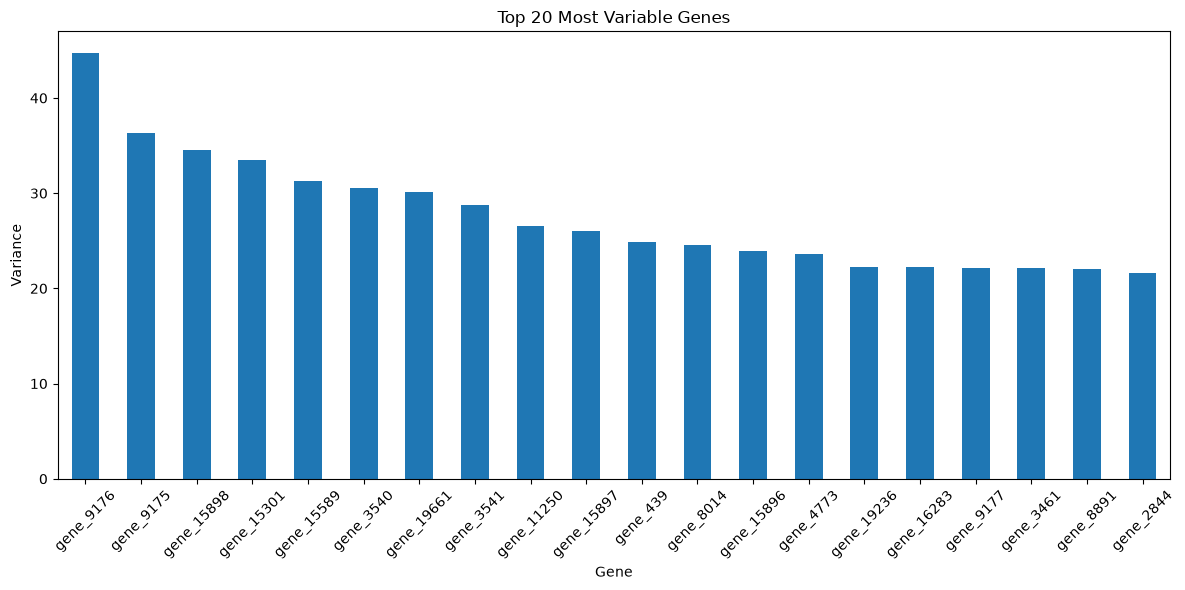

In [11]:
plt.figure(figsize=(12,6))

top_20_variance.plot(kind="bar")

plt.title("Top 20 Most Variable Genes")
plt.xlabel("Gene")
plt.ylabel("Variance")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [12]:
# Summary statistics of gene variances
print(gene_variances.describe())

count    20531.000000
mean         1.764138
std          2.574352
min          0.000000
25%          0.343816
50%          0.801383
75%          2.173090
max         44.763849
dtype: float64


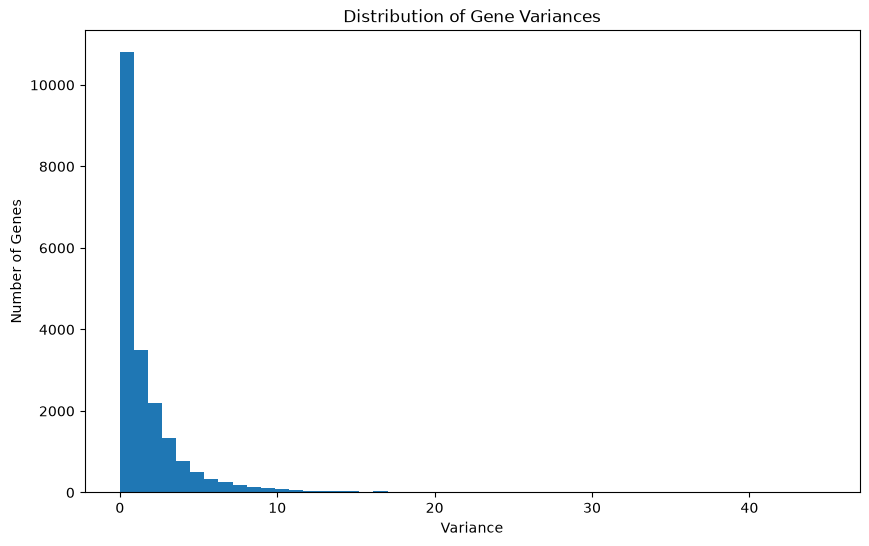

In [13]:
plt.figure(figsize=(10,6))

plt.hist(gene_variances, bins=50)

plt.title("Distribution of Gene Variances")

plt.xlabel("Variance")

plt.ylabel("Number of Genes")

plt.show()

In [14]:
print(gene_variances.describe())

count    20531.000000
mean         1.764138
std          2.574352
min          0.000000
25%          0.343816
50%          0.801383
75%          2.173090
max         44.763849
dtype: float64


In [15]:
variance_threshold = gene_variances.median()

selected_genes = gene_variances[
    gene_variances > variance_threshold
].index

filtered_expression_df = expression_df[selected_genes]

In [16]:
print("Original number of genes:")
print(expression_df.shape[1])

print("\nRemaining genes after variance filtering:")
print(filtered_expression_df.shape[1])

Original number of genes:
20531

Remaining genes after variance filtering:
10265


In [17]:
filtered_expression_df.to_csv(
    "../data/processed/variance_filtered_expression.csv"
)

print("Filtered dataset saved successfully!")

Filtered dataset saved successfully!


In [18]:
from sklearn.feature_selection import SelectKBest, f_classif

In [19]:
%whos

Variable                 Type         Data/Info
-----------------------------------------------
SelectKBest              ABCMeta      <class 'sklearn.feature_s<...>e_selection.SelectKBest'>
expression_df            DataFrame    Shape: (801, 20531)
f_classif                function     <function f_classif at 0x1188f1b10>
filtered_expression_df   DataFrame    Shape: (801, 10265)
gene_variances           Series       Shape: (20531,)
labels_df                DataFrame    Shape: (801, 2)
np                       module       <module 'numpy' from '/Us<...>kages/numpy/__init__.py'>
pd                       module       <module 'pandas' from '/U<...>ages/pandas/__init__.py'>
plt                      module       <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
selected_genes           Index        Index(['gene_1', 'gene_2'<...>type='str', length=10265)
top_20_variance          Series       Shape: (20,)
variance_threshold       float64      0.8013826352531614


In [21]:
X_variance_filtered = filtered_expression_df

y = labels_df["Class"]

In [22]:
selector = SelectKBest(
    score_func=f_classif,
    k=500
)

X_selected = selector.fit_transform(
    X_variance_filtered,
    y
)

In [23]:
selected_gene_names = X_variance_filtered.columns[
    selector.get_support()
]

selected_gene_names[:10]

Index(['gene_18', 'gene_30', 'gene_89', 'gene_145', 'gene_148', 'gene_172',
       'gene_180', 'gene_203', 'gene_219', 'gene_220'],
      dtype='str')

In [24]:
anova_selected_df = pd.DataFrame(
    X_selected,
    columns=selected_gene_names
)

anova_selected_df.head()

,gene_18,gene_30,gene_89,gene_145,gene_148,gene_172,gene_180,gene_203,gene_219,gene_220,...,gene_19356,gene_19373,gene_19563,gene_19606,gene_19623,gene_19669,gene_19914,gene_20109,gene_20208,gene_20392
0,0.591871,0.0,13.230181,8.126338,9.920593,2.717803,0.000000,15.673080,0.591871,0.591871,...,6.991885,0.000000,8.315059,10.882658,8.542045,3.410884,11.919474,10.974321,9.527078,11.995986
1,0.000000,0.0,8.885272,7.036613,4.256241,5.019729,1.813607,9.184930,0.000000,0.000000,...,11.231563,0.811142,9.422389,0.811142,9.968768,10.081230,4.095722,7.161001,10.755497,8.338540
2,1.683023,0.0,13.892087,9.938817,11.209130,3.352236,0.000000,13.804736,0.000000,0.452595,...,5.644136,1.981122,7.017966,10.021841,10.844745,2.438799,9.526732,7.353200,8.997157,9.050276
3,1.267356,0.0,14.982962,8.302831,10.286327,2.058697,0.000000,17.472493,1.039419,0.434882,...,7.503571,0.768587,7.821111,10.890036,7.933331,2.283833,11.807347,10.240911,9.599653,10.568213
4,0.889707,0.0,6.477750,7.908681,1.095654,2.801097,3.525831,4.056150,0.000000,0.000000,...,10.469164,0.000000,8.896599,10.404290,9.738265,4.056150,11.542147,8.234540,9.626065,9.177945


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [26]:
feature_sizes = [100, 250, 500, 1000]

results = []

In [27]:
for k in feature_sizes:

    selector = SelectKBest(
        score_func=f_classif,
        k=k
    )

    X_selected = selector.fit_transform(
        filtered_expression_df,
        y
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X_selected,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    results.append({
        "Number of Genes": k,
        "Accuracy": accuracy
    })

In [28]:
comparison_df = pd.DataFrame(results)

comparison_df

,Number of Genes,Accuracy
0,100,0.987578
1,250,0.993789
2,500,0.993789
3,1000,0.993789


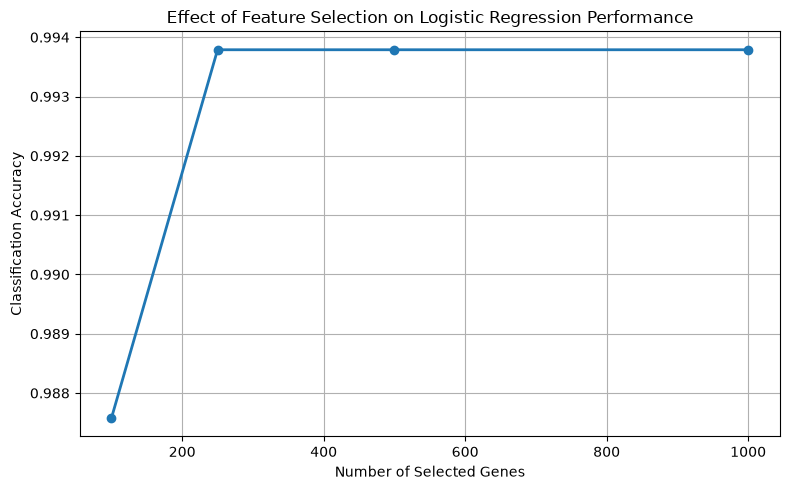

In [29]:
import os

os.makedirs(
    "../results/figures/feature_engineering",
    exist_ok=True
)

plt.figure(figsize=(8,5))

plt.plot(
    comparison_df["Number of Genes"],
    comparison_df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Selected Genes")
plt.ylabel("Classification Accuracy")
plt.title("Effect of Feature Selection on Logistic Regression Performance")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../results/figures/feature_engineering/feature_selection_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/figures/feature_engineering/feature_selection_comparison.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close()

In [30]:
best_result = comparison_df.loc[
    comparison_df["Accuracy"].idxmax()
]

best_result

Number of Genes    250.000000
Accuracy             0.993789
Name: 1, dtype: float64

In [31]:
print(comparison_df)

   Number of Genes  Accuracy
0              100  0.987578
1              250  0.993789
2              500  0.993789
3             1000  0.993789


In [32]:
best_k = 250

selector = SelectKBest(
    score_func=f_classif,
    k=best_k
)

X_final = selector.fit_transform(
    filtered_expression_df,
    y
)

selected_gene_names = filtered_expression_df.columns[
    selector.get_support()
]

final_feature_df = pd.DataFrame(
    X_final,
    columns=selected_gene_names
)

In [33]:
final_feature_df.to_csv(
    "../data/processed/final_feature_dataset.csv",
    index=False
)

print(final_feature_df.shape)

(801, 250)
